# Метод 1 — CatBoost. Часть 3: оценка, Split CP, монотонность

В этом ноутбуке посчитаны holdout SMLAR, монотонные нарушения и Split CP-покрытие

In [1]:
from __future__ import annotations

import sys
import json
from pathlib import Path

ROOT = Path('/Users/ensamsanovich/auc_forecast')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

OUT_DIR = ROOT / 'outputs' / 'method_1_catboost'
OUT_DIR.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from catboost import CatBoostRegressor

from core.ci import ConformalEvaluation, aggregate_cp_coverage, seeded_train_calib_split
from core.config import ALPHA, INNER_CALIB_FRAC, MODEL_DIR, SEED, TARGETS, set_seed
from core.conformal import MultiTargetSplitCP
from core.leak_safe_features import build_leak_safe_aggregates
from core.metrics import monotonicity_violation, smlar, smlar_per_target
from core.reporting import make_result, save_method_results
from core.runner import load_unified_data

set_seed()

In [2]:
data = load_unified_data()
split = data['split']

X = build_leak_safe_aggregates(data['val'], data['user_index'], data['pub_index'])
y = data['ans'][list(TARGETS)].astype(float)

train_idx = split['train_idx']
holdout_idx = split['holdout_idx']
folds = split['folds']

print(f"X: {X.shape}, y: {y.shape}")
print(f"train: {len(train_idx)}, holdout: {len(holdout_idx)}, фолдов: {len(folds)}")

X: (1008, 39), y: (1008, 3)
train: 806, holdout: 202, фолдов: 5


### Загрузка Optuna-модели

In [3]:
model_path = MODEL_DIR / 'best_catboost_optuna.cbm'

model_params_fallback = {
    'iterations': 800,
    'depth': 6,
    'learning_rate': 0.05,
    'loss_function': 'MultiRMSE',
    'verbose': 0,
    'random_seed': SEED,
    'allow_writing_files': False,
}

full_model = CatBoostRegressor()
if model_path.exists():
    print(f"Загружаем модель: {model_path}")
    full_model.load_model(str(model_path))
    cb_params_used = {'loaded_from': str(model_path)}
else:
    print(f"Модель не найдена по пути {model_path}")
    full_model = CatBoostRegressor(**model_params_fallback)
    full_model.fit(X.iloc[train_idx].values, y.iloc[train_idx].values)
    MODEL_DIR.mkdir(exist_ok=True)
    full_model.save_model(str(model_path))
    cb_params_used = model_params_fallback

Загружаем модель: /Users/ensamsanovich/auc_forecast/model/best_catboost_optuna.cbm


### Holdout-метрики

In [4]:
pred_ho = np.clip(full_model.predict(X.iloc[holdout_idx].values), 0.0, 1.0)
y_ho = y.iloc[holdout_idx].values

ho_smlar = smlar(y_ho, pred_ho)
ho_per_target = smlar_per_target(y_ho, pred_ho)
ho_mono = monotonicity_violation(pred_ho)

print(f"Holdout SMLAR (flat):       {ho_smlar:.3f}%")
print(f"Holdout SMLAR per-target:    {ho_per_target}")
print(f"Holdout монотонные наруш.:   {ho_mono*100:.2f}%")

Holdout SMLAR (flat):       33.660%
Holdout SMLAR per-target:    {'at_least_one': np.float64(46.449716162164066), 'at_least_two': np.float64(33.44157121055895), 'at_least_three': np.float64(22.18713263657921)}
Holdout монотонные наруш.:   4.95%


### CV-метрики и Split CP-покрытие

In [5]:
try:
    cb_params = full_model.get_all_params()
    cb_params['verbose'] = 0
    cb_params['allow_writing_files'] = False
    cb_params['random_seed'] = SEED
except Exception:
    cb_params = dict(model_params_fallback)

fold_smlar = []
fold_mono = []
cp_evals = []
for fold_i, (tr, va) in enumerate(folds):
    n_tr = len(tr)
    sub_local, cal_local = seeded_train_calib_split(n_tr, INNER_CALIB_FRAC, SEED + fold_i)
    sub_idx = tr[sub_local]
    cal_idx = tr[cal_local]
    VALID_CB_PARAMS = {
        'iterations', 'learning_rate', 'depth', 'l2_leaf_reg',
        'bagging_temperature', 'random_strength', 'border_count',
        'leaf_estimation_iterations', 'min_data_in_leaf',
        'subsample', 'colsample_bylevel', 'grow_policy',
        'max_leaves', 'boosting_type', 'od_type', 'od_wait',
        'random_seed', 'verbose', 'allow_writing_files','loss_function',
    }

    cb_params_clean = {k: v for k, v in cb_params.items() if k in VALID_CB_PARAMS}
    model = CatBoostRegressor(**cb_params_clean)
    # model = CatBoostRegressor(**cb_params)
    model.fit(X.iloc[sub_idx].values, y.iloc[sub_idx].values)
    pred_cal = np.clip(model.predict(X.iloc[cal_idx].values), 0.0, 1.0)
    pred_va = np.clip(model.predict(X.iloc[va].values), 0.0, 1.0)

    fold_smlar.append(smlar(y.iloc[va].values, pred_va))
    fold_mono.append(monotonicity_violation(pred_va))

    cp = MultiTargetSplitCP(alpha=ALPHA).calibrate(y.iloc[cal_idx].values, pred_cal)
    lo, hi = cp.predict(pred_va)
    cp_evals.append(ConformalEvaluation(
        y_true=y.iloc[va].values.astype(np.float64),
        y_pred=pred_va.astype(np.float64),
        lower=lo, upper=hi,
        quantiles_per_target=[float(c.quantile_) for c in cp.per_target_],
    ))

cv_smlar_mean = float(np.mean(fold_smlar))
cv_smlar_std = float(np.std(fold_smlar, ddof=0))
cv_mono_mean = float(np.mean(fold_mono))
cp_agg = aggregate_cp_coverage(cp_evals)

print(f"CV SMLAR: {cv_smlar_mean:.3f}% ± {cv_smlar_std:.3f}")
print(f"CV монотонные нарушения: {cv_mono_mean*100:.2f}%")
print(f"CP coverage per target: {cp_agg['coverage_per_target']}")
print(f"CP width per target:    {cp_agg['width_per_target']}")

CV SMLAR: 41.243% ± 4.949
CV монотонные нарушения: 6.95%
CP coverage per target: {'at_least_one': 0.882163944482785, 'at_least_two': 0.8933900774480484, 'at_least_three': 0.8958515451269076}
CP width per target:    {'at_least_one': 0.12085960244263172, 'at_least_two': 0.08797892419330611, 'at_least_three': 0.0711977473727156}


### 6. Серия PNG-кадров: проверка монотонности предсказаний

Выбираем 20 кампаний из holdout и рисуем для каждой столбчатую диаграмму (y1, y2, y3). Если y1<y2 или y2<y3 — заголовок и фон подсвечены красным.

In [6]:
rng = np.random.default_rng(SEED)
n_pick = min(20, len(holdout_idx))
selected = rng.choice(len(holdout_idx), size=n_pick, replace=False)
selected.sort()

labels = list(TARGETS)
viol_flags = []
for step, local_i in enumerate(selected, start=1):
    p = pred_ho[local_i]
    yt = y_ho[local_i]
    y1, y2, y3 = float(p[0]), float(p[1]), float(p[2])
    violated = (y1 < y2) or (y2 < y3)
    viol_flags.append(violated)

    fig, ax = plt.subplots(figsize=(7, 4.5))
    colors = ['#d62728' if violated else '#1f77b4'] * 3
    x_pos = np.arange(3)
    ax.bar(x_pos - 0.18, [y1, y2, y3], width=0.36, color=colors, alpha=0.85, label='predict')
    ax.bar(x_pos + 0.18, list(yt), width=0.36, color='#2ca02c', alpha=0.55, label='true')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, rotation=0)
    ax.set_ylim(0, max(1.0, max(y1, y2, y3, float(yt.max())) * 1.15))
    ax.set_ylabel('доля')
    status = 'VIOLATION' if violated else 'OK'
    ax.set_title(f'Holdout-кампания #{step}/{n_pick}, локальный idx={local_i}: {status}')
    if violated:
        ax.set_facecolor('#fde0e0')
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend(loc='upper right')
    fig.tight_layout()
    fig.savefig(OUT_DIR / f'fig_mono_campaign_{step:03d}.png', dpi=110)
    plt.close(fig)

print(f"Сохранено {n_pick} кадров; нарушения: {sum(viol_flags)}/{n_pick}")

Сохранено 20 кадров; нарушения: 2/20


### 7. Сохранение unified-результата

In [7]:
result = make_result(
    method='catboost-optuna',
    split_protocol=split['protocol'],
    leak_safe=True,
    features='leak-safe 39-feat aggregates',
    cv_smlar_flat_mean=cv_smlar_mean,
    cv_smlar_flat_std=cv_smlar_std,
    cv_smlar_per_target=None,
    cv_monotone_viol_mean=cv_mono_mean,
    holdout_smlar=float(ho_smlar),
    holdout_monotone_viol=float(ho_mono),
    ci_type='split_cp',
    ci_alpha=ALPHA,
    ci_coverage_per_target=cp_agg['coverage_per_target'],
    ci_width_per_target=cp_agg['width_per_target'],
    source='notebook 03_evaluation_and_results',
    extra={
        'holdout_smlar_per_target': ho_per_target,
        'cb_params_used': cb_params_used,
        'n_holdout': int(len(holdout_idx)),
        'n_train': int(len(train_idx)),
    },
)

saved_path = save_method_results('catboost', result)
print(f"Результаты сохранены: {saved_path}")

Результаты сохранены: /Users/ensamsanovich/auc_forecast/results/per_method/catboost.json


### 8. Финальный кадр и краткая сводка

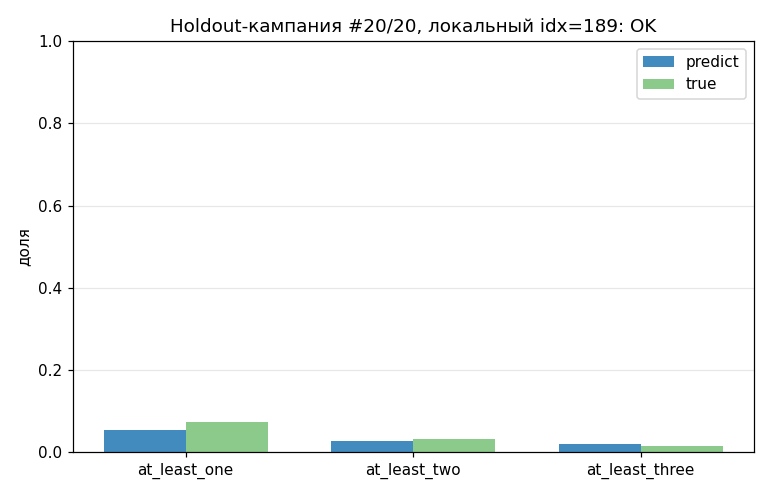

In [8]:
last_frame = OUT_DIR / f'fig_mono_campaign_{n_pick:03d}.png'
if last_frame.exists():
    display(Image(filename=str(last_frame)))

In [9]:
summary = pd.DataFrame({
    'metric': [
        'CV SMLAR mean (%)',
        'CV SMLAR std (%)',
        'CV monotone violations (%)',
        'Holdout SMLAR (%)',
        'Holdout monotone violations (%)',
        'CP coverage at_least_one',
        'CP coverage at_least_two',
        'CP coverage at_least_three',
    ],
    'value': [
        round(cv_smlar_mean, 3),
        round(cv_smlar_std, 3),
        round(cv_mono_mean * 100, 3),
        round(float(ho_smlar), 3),
        round(float(ho_mono) * 100, 3),
        cp_agg['coverage_per_target'].get('at_least_one'),
        cp_agg['coverage_per_target'].get('at_least_two'),
        cp_agg['coverage_per_target'].get('at_least_three'),
    ],
})
summary

,metric,value
0,CV SMLAR mean (%),41.243000
1,CV SMLAR std (%),4.949000
2,CV monotone violations (%),6.951000
3,Holdout SMLAR (%),33.660000
4,Holdout monotone violations (%),4.950000
5,CP coverage at_least_one,0.882164
6,CP coverage at_least_two,0.893390
7,CP coverage at_least_three,0.895852


### Результаты

- Рассчитаны CV и holdout-метрики SMLAR.
- Получены покрытие и ширина Split CP-интервалов на уровне `alpha=0.10`.
- Сохранено 20 PNG-кадров с проверкой монотонности предсказаний по holdout-кампаниям.